In [1]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [ ]:
# https://github.com/moshi4/pyCirclize

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_example_tree_file
from Bio import Phylo

In [17]:
phylogeny = Phylo.read(r"../../data/chapter2/uphylomaker/collab_fineroots_log_995_species_means_5states.tre", format="newick")
data = pd.read_csv(r"../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states_name_matched_with_phylogeny.csv")

In [18]:
phylogeny.total_branch_length()

31862.196965946

In [19]:
phylogeny.count_terminals() # tips are called terminals here

995

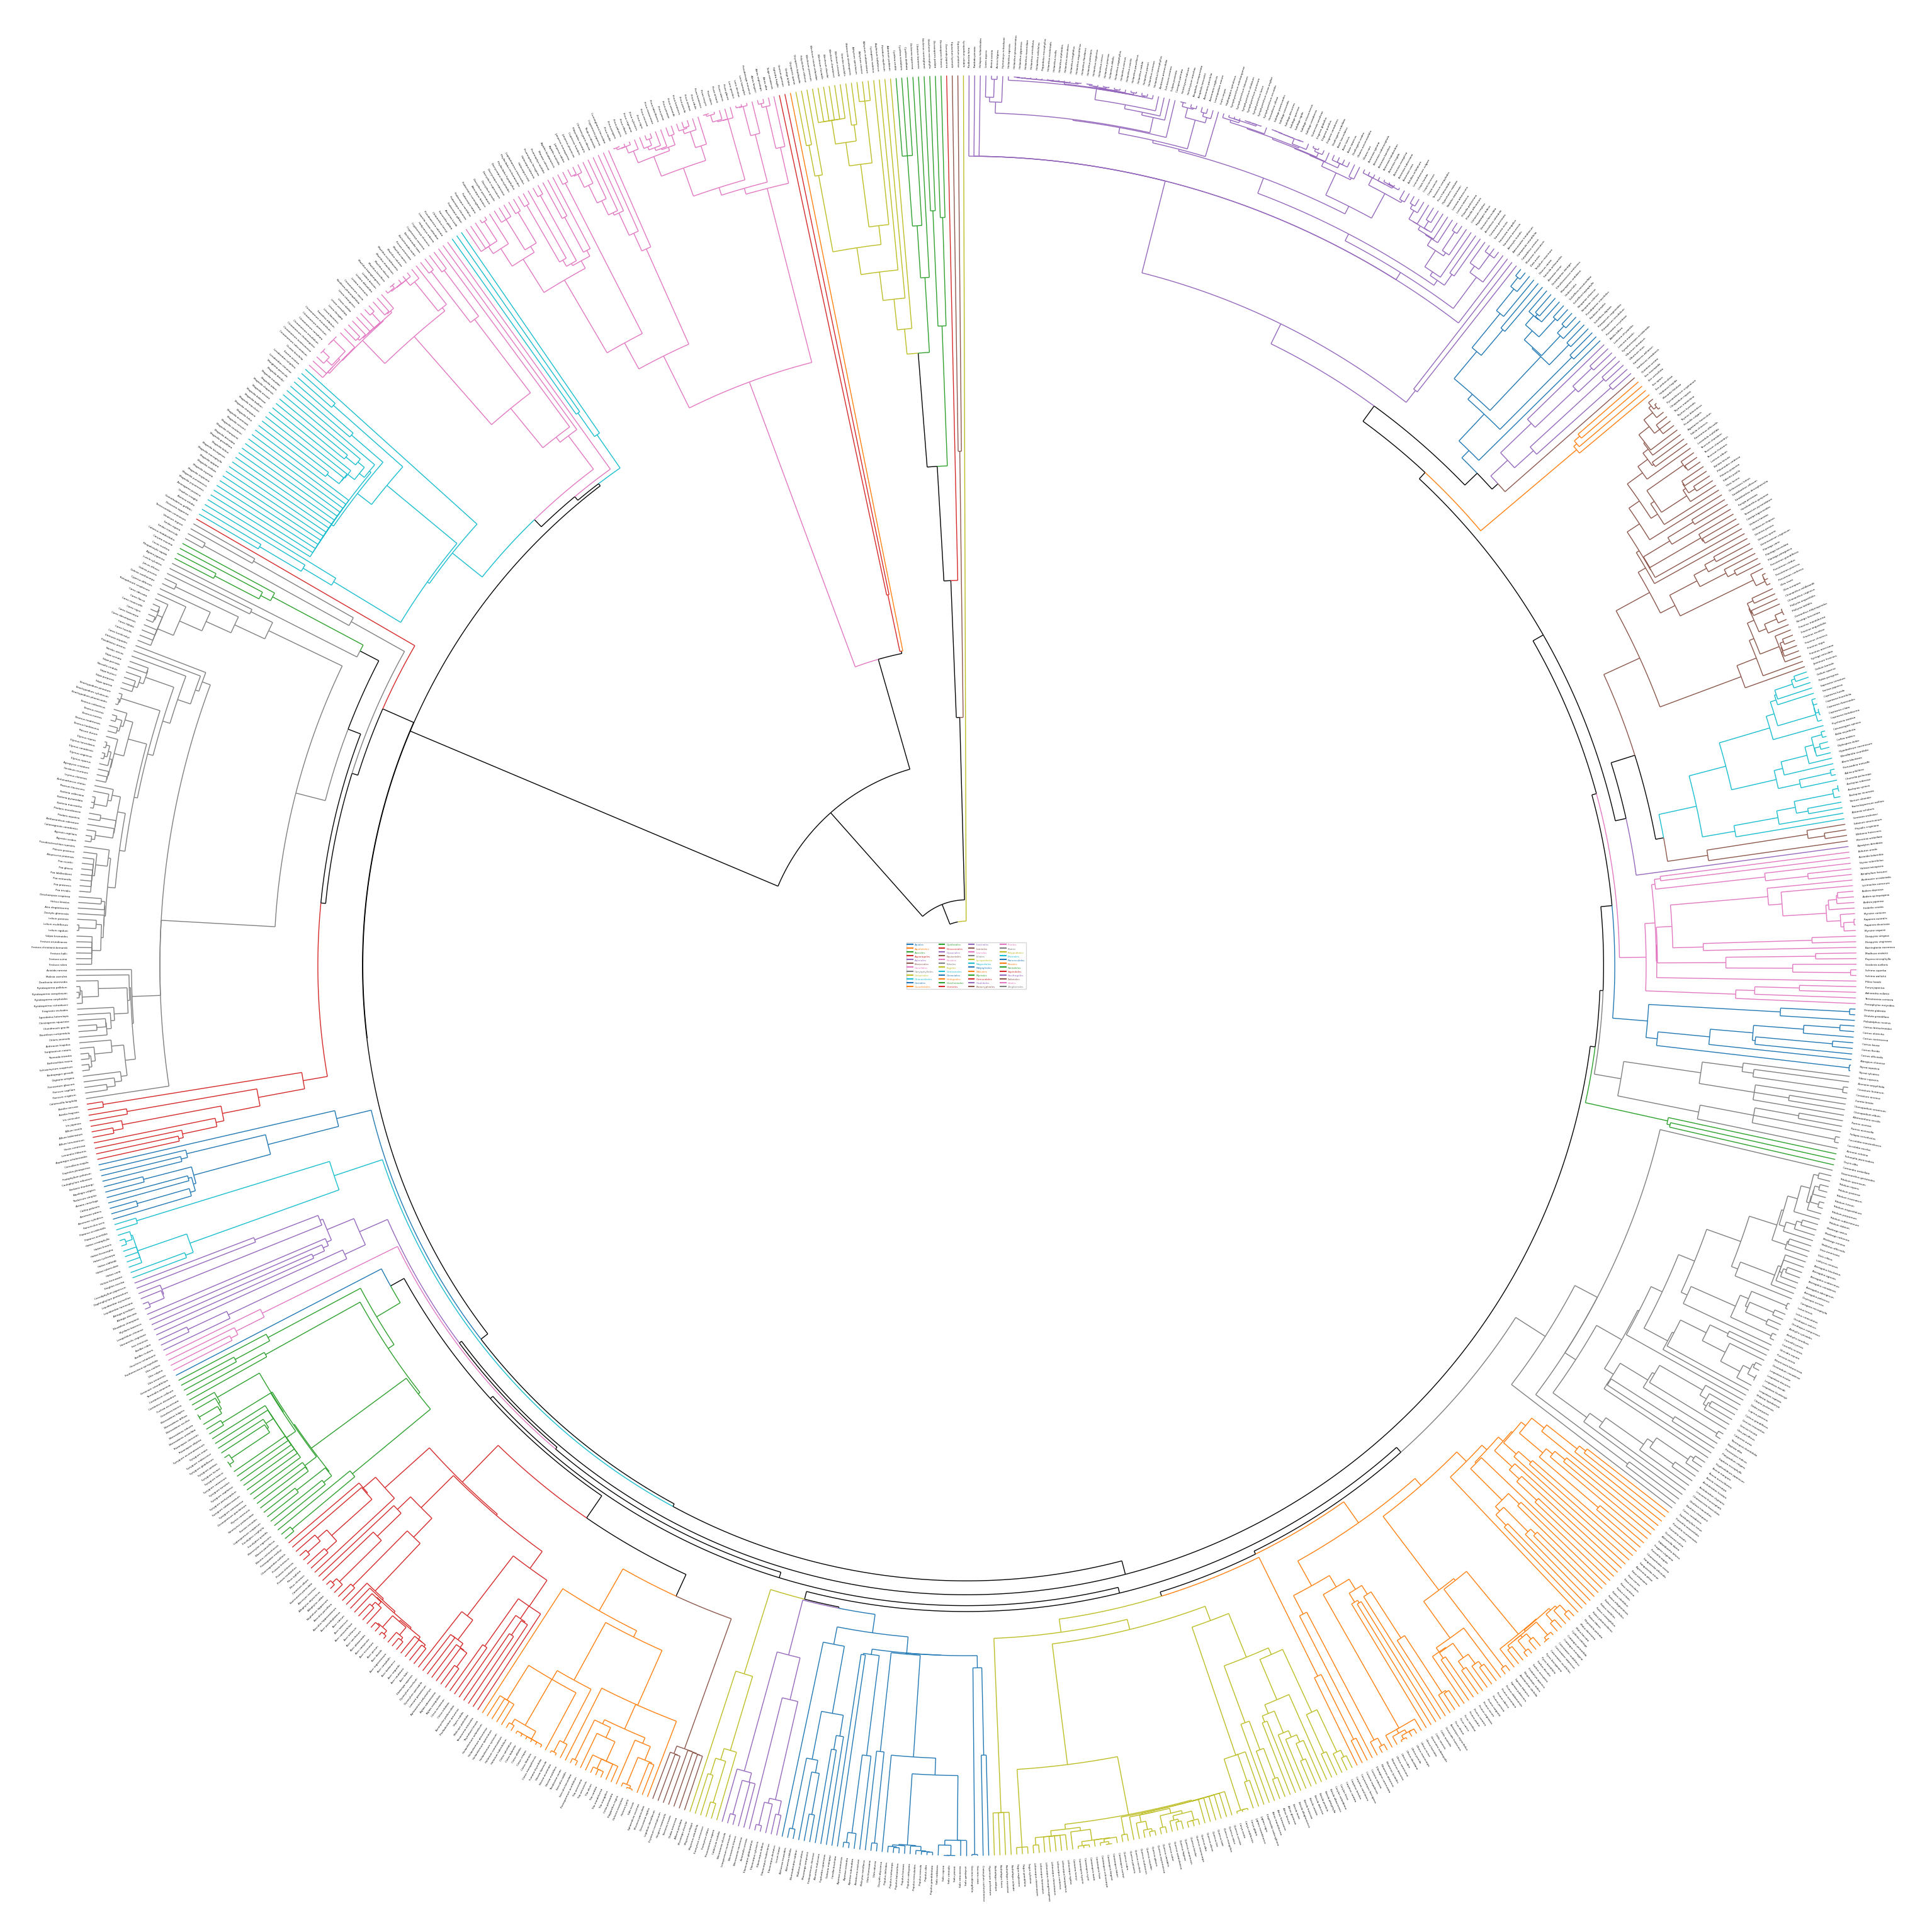

In [34]:
circos, tv = Circos.initialize_from_tree(tree_data=phylogeny, r_lim=(5, 100), leaf_label_size=3, line_kws=dict(color="black", lw=1.0), align_leaf_label=True, # initialize Circos from phylogenetic tree
                                         leaf_label_rmargin=1, label_formatter=lambda name: name.replace('_', ' ')) 
order_species_dict = {order: tuple(df.binominal) for (order, df) in data.groupby("F01290")} # define group-species dict for tree annotation
ColorCycler.set_cmap("tab10") # lots of colours get repeated here though??????
order_colour = {order: ColorCycler() for order  in order_species_dict}

for order, species in order_species_dict.items():
    colour = order_colour[order]
    tv.set_node_line_props(species, color=colour, apply_label_color=False) # don't colour the labels

# plot figure & set legend on center
fig = circos.plotfig()
fig.set_size_inches(30, 30)
circos.ax.legend(handles=[Line2D([], [], label=order, color=colour) for (order, colour) in order_colour.items()], labelcolor=order_colour.values(), fontsize=3, loc="center",
                 bbox_to_anchor=(0.5, 0.5), ncols=4)

# plt.show()
plt.savefig(r"./dummyphylogeny.png", dpi=800)

In [ ]:
# http://www.phytools.org/Cordoba2017/ex/15/Plotting-methods.html